<div style="text-align:left;">
  <p><em>Prepared by Latreche Sara</em></p>
</div>

<center><font size=6><b>Model benchmark and evaluation</b></font></center>

<div style="text-align:center;">
    <img src="./assets/california.PNG" width="450"/>
</div>

***

**Author**: Latreche Sara  
**Date**: June 2026  

### Table of Contents

- [1 | Pipeline Architecture & Objectives](#1-pipeline-architecture)
- [2 | Environment Setup & Dataset Loading](#2-setup)
- [3 | Feature Engineering & Robust Preprocessing Pipeline](#3-preprocessing)
- [4 | Benchmark of different models](#4-benchmark)
- [5 | Model Evaluation](#5-tuning)


## <b><a id="2-setup">2 <span style='color:#770A7A'>|</span> Environment Setup & Dataset Loading</a></b>
*Environment initialization, importing core libraries (Scikit-Learn, XGBoost, LightGBM, CatBoost, SHAP), and loading the clean file `cleaned_dataset.csv`.*

In [40]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, RobustScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

In [41]:
df= pd.read_csv("data.csv")

## <b><a id="3-preprocessing">3 <span style='color:#770A7A'>|</span> Feature Engineering & Robust Preprocessing Pipeline</a></b>
*Execution of the standard `train_test_split` (with verified distributional stability over 74k rows) and configuration of the `ColumnTransformer`. We employ a `RobustScaler` (leveraging the median and Interquartile Range - IQR) to neutralize the long, skewed tails observed in our boxplots without discarding valid high-end property information, paired with a `OneHotEncoder` for categorical dimensions.*


In [42]:
# split the features and target variable 
X= df.drop("median_house_value",axis=1)  
y=df["median_house_value"]


In [43]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [44]:
# ==========================================
# 1. PREPARE DATA & SPLIT
# ==========================================
# Split features and target vector (California Housing)
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [45]:
# Identify numerical vs categorical columns automatically
num_cols= X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols= X.select_dtypes(exclude=[np.number]).columns.tolist()


In [46]:
# Identify numerical vs categorical columns automatically
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

## <b><a id="3-preprocessing">3 <span style='color:#770A7A'>|</span> Feature Engineering & Robust Preprocessing Pipeline</a></b>
*Execution of the standard `train_test_split` (with verified distributional stability over 74k rows) and configuration of the `ColumnTransformer`. We employ a `RobustScaler` (leveraging the median and Interquartile Range - IQR) to neutralize the long, skewed tails observed in our boxplots without discarding valid high-end property information, paired with a `OneHotEncoder` for categorical dimensions.*

In [47]:
# ==========================================
# 2. HANDS-ON ML COMPLIANT PREPROCESSING PIPELINE
# ==========================================
# Robust scaling handles extreme outliers using Median & IQR
num_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
    ]
)

# One-Hot Encoding handles non-ordered nominal values safely (ocean_proximity)
cat_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

In [48]:
# Combine transformers into the main preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),
        ("cat", cat_transformer, cat_cols),
    ]
)

## <b><a id="4-benchmark">4 <span style='color:#770A7A'>|</span> Training different models</a></b>


In [51]:
# ==========================================
# 3. EXPANDED MODELS DICTIONARY FOR COMPARISON
# ==========================================
models = {
    "Linear Regression": LinearRegression(),
    "Lasso Regression": Lasso(alpha=1.0, max_iter=10000),
    "Ridge Regression": Ridge(alpha=1.0),
    "Support Vector Regressor": SVR(),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100, random_state=42, n_jobs=-1
    ),
}

In [53]:
# ==========================================================
# 4. RUN AUTOMATED TRAINING & ADJUSTED PERFORMANCE METRICS
# ==========================================================
results = []
n = X_test.shape[0]  # Number of data points in your test set

# Calculate the exact feature count (p) once outside the loop
p = preprocessor.fit_transform(X_train).shape[1]

for name, model in models.items():
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])

    # Fit pipeline
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    # Standard metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Calculate Adjusted R2 using the evaluation set metrics and dimensions
    adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

    results.append(
        {
            "Model": name,
            "R2 Score": r2,
            "Adjusted R2": adj_r2,
            "MAE": mae,
            "RMSE": rmse,
        }
    )

In [55]:
# Sort performance leader board by Adjusted R2
df_results = pd.DataFrame(results).sort_values(
    by="Adjusted R2", ascending=False
)
print("\n--- Model Performance Leaderboard (Adjusted for Features) ---")
print(df_results.to_string(index=False))


--- Model Performance Leaderboard (Adjusted for Features) ---
                   Model  R2 Score  Adjusted R2          MAE          RMSE
           Random Forest  0.817027     0.816449 31623.509944  48966.202249
           KNN Regressor  0.704726     0.703793 41913.667442  62203.634089
           Decision Tree  0.634214     0.633058 43669.009205  69233.603171
       Linear Regression  0.625438     0.624255 50670.489236  70059.193339
        Lasso Regression  0.625429     0.624246 50671.063514  70060.018369
        Ridge Regression  0.625373     0.624190 50673.433553  70065.255118
Support Vector Regressor -0.042453    -0.045747 87016.292504 116877.683485


## <b><a id="5-tuning">5 <span style='color:#770A7A'>|</span> Model Evaluation</a></b>


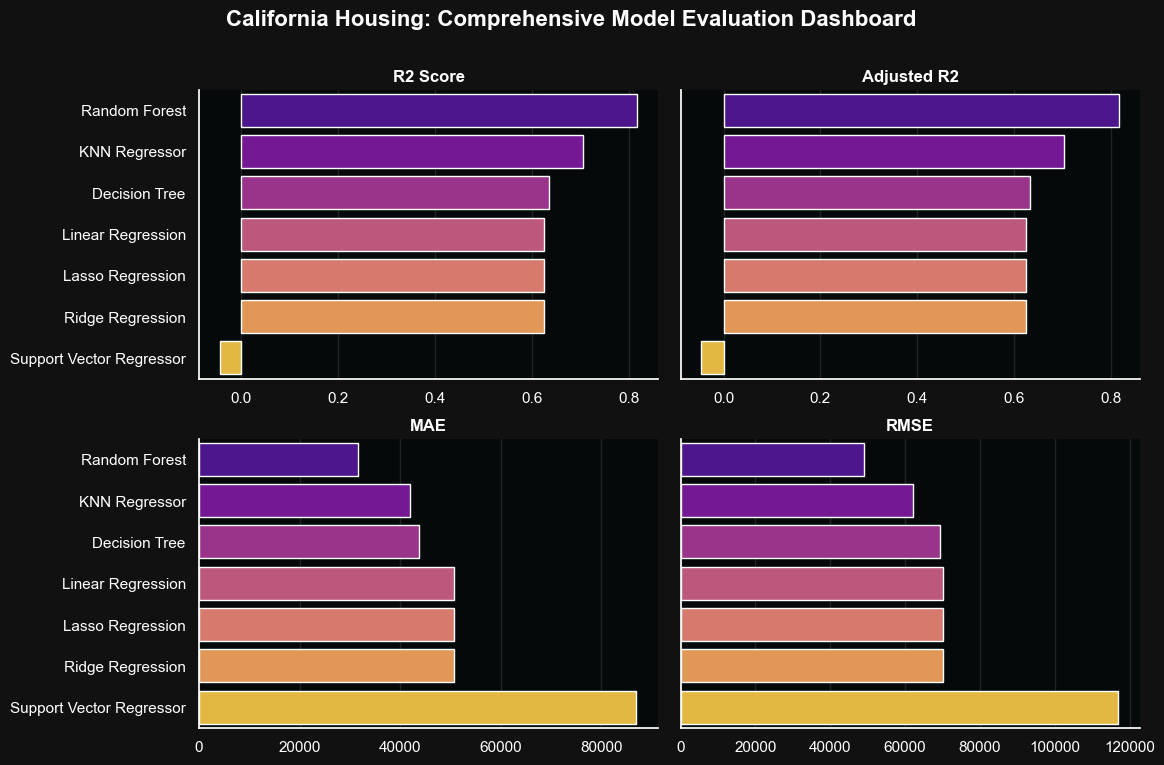

In [56]:
# ==========================================
# 5. VISUAL EVALUATION COMPONENT (ALL METRICS)
# ==========================================
# 1. Melt the results dataframe into long-form for easy grid plotting
df_melted = pd.melt(
    df_results, id_vars=["Model"], var_name="Metric", value_name="Value"
)

# 2. Setup your signature dark theme styling
sns.set_theme(
    style="darkgrid",
    rc={
        "figure.facecolor": "#111111",
        "axes.facecolor": "#05090a",
        "grid.color": "#202324",
        "text.color": "white",
        "xtick.color": "white",
        "ytick.color": "white",
    },
)

# 3. Create a 2x2 grid framework for the 4 metrics
g = sns.catplot(
    data=df_melted,
    x="Value",
    y="Model",
    col="Metric",
    col_wrap=2,  # Arranges plots into a neat 2x2 layout matrix
    kind="bar",
    palette="plasma",
    hue="Model",
    sharex=False,  # Each metric has completely different scales
    height=4,
    aspect=1.5,
)

# 4. Clean up titles, axes, and canvas layout
g.set_titles("{col_name}", color="white", weight="bold", size=12)
g.set_xlabels("")  # Corrected function name
g.set_ylabels("")  # Corrected function name

# Adjust background elements for the facet subplots explicitly
for ax in g.axes.flatten():
    ax.set_facecolor("#05090a")
    ax.tick_params(colors="white")

# Add an overarching dashboard title
plt.subplots_adjust(top=0.88)
g.fig.suptitle(
    "California Housing: Comprehensive Model Evaluation Dashboard",
    color="white",
    fontsize=16,
    fontweight="bold",
)

plt.show()